In [222]:
import numpy as np
import sklearn.linear_model as linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


**Note**. Some of the functions imported above will be useful, and in a few cases explicitly required, in the exercises below.

# 1 Polynomial Regression with SGD

In this exercise we revisit overfitting and underfitting using polynomial regression.
Instead of solving the linear least-squares problem analytically, as in Exercise 2, we will minimize the loss with stochastic gradient descent (SGD).


The following function generates data from a polynomial of degree $d$ with coefficients $\{c_k\}_{k=0}^{d}$ and additive Gaussian noise of standard deviation $\xi$:

$$
y_i = \sum_{k=0}^{d} c_k x_i^k + \xi\,\mathcal N(0,1),
$$

where the inputs $x_i$ are sampled uniformly from a bounded interval.


In [223]:
# This function generates data from a polynomial, possibly with noise
def generate_polynomial_data(polynomial, noise_std, n, bound, seed):
    """
    Arguments:
        polynomial : coefficients, with polynomial[k] multiplying x**k
        noise_std  : standard deviation of the Gaussian noise
        n          : number of data points
        bound      : sample x uniformly from [-bound, bound]
        seed       : random seed
    Returns:
        X, y       : n inputs and corresponding noisy targets
    """
    rng = np.random.default_rng(seed)
    x = rng.uniform(-bound, bound, size=n)
    powers = np.vander(x, N=len(polynomial), increasing=True)
    y = powers @ polynomial + rng.normal(0.0, noise_std, size=n)
    return x.reshape(-1, 1), y


## 1.1 Generate data

Generate $n=20$ noisy training points from

$$
y = x^2 + 0.5x^3
$$

on the interval $[-3,3]$. We use a small dataset so that the effect of model complexity on overfitting is visible.


In [224]:
# Create 20 noisy data points in the training interval [-3, 3]
n = 20
train_bound = 3.0
noise_std = 1.0
polynomial = np.array([0.0, 0.0, 1.0, 0.5])
X_train, y_train = generate_polynomial_data(
    polynomial, noise_std, n, train_bound, seed=42
)


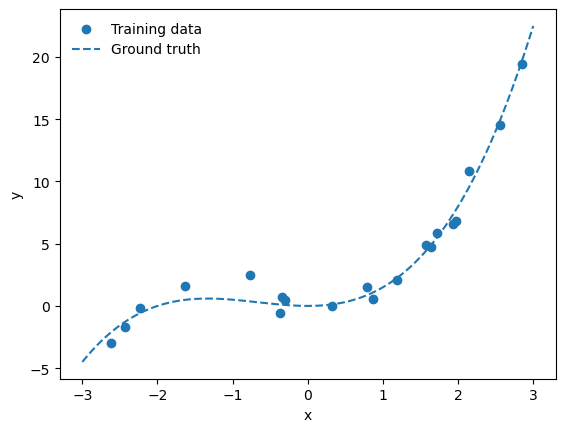

In [225]:
# Show the training data and the noise-free polynomial
x_plot = np.linspace(-train_bound, train_bound, 300).reshape(-1, 1)
y_plot = x_plot[:, 0] ** 2 + 0.5 * x_plot[:, 0] ** 3

plt.scatter(X_train[:, 0], y_train, label="Training data")
plt.plot(x_plot[:, 0], y_plot, linestyle="--", label="Ground truth")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(frameon=False)
plt.show()


We also generate a large independent synthetic evaluation set.

Our data-distribution (and our exercise) is synthetic. For real datasets, to choose the model complexity one should **not** repeatedly use the test set, but rather use a validation set for that purpose.


In [226]:
n_test = 2000
X_test, y_test = generate_polynomial_data(
    polynomial, noise_std, n_test, train_bound, seed=43
)


## 1.2 Polynomials of different degrees

To keep the polynomial features numerically well behaved, first rescale the input as

$$
z = \frac{x}{3}\in[-1,1],
$$

and use the features

$$
\phi_k(x)=z^k, \qquad k=0,\ldots,d.
$$

The model is

$$
\hat y_i = \sum_{k=0}^d c_k\phi_k(x_i),
$$

and we train it with the regularized loss

$$
L(c)=\frac{1}{2n}\sum_{i=1}^n (y_i-\hat y_i)^2
+\lambda\frac{1}{d+1}\sum_{k=0}^d c_k^2.
$$

For simplicity, the regularizer acts on all coefficients, including the intercept $c_0$.

Show that

$$
\boxed{
\frac{\partial L}{\partial c_k}
=-\frac{1}{n}\sum_{i=1}^n (y_i-\hat y_i)\phi_k(x_i)
+\frac{2\lambda}{d+1}c_k
}.
$$

The rescaling $x\mapsto x/3$ helps to avoid overflow while keeping the higher-degree features numerically relevant.


We now write the functions needed to compute the feature matrix, predictions, loss, and gradient.


In [227]:
# Function that generates the feature matrix
def create_features(X, d, scale=3.0):
    z = X[:, 0] / scale
    return np.vander(z, N=d + 1, increasing=True)


In [228]:
# Function to predict the labels
def predict_label(X_features, c):
    return X_features @ c


In [229]:
# Function to compute the regularized loss
def loss(X_features, y, c, lambd):
    y_pred = predict_label(X_features, c)
    data_term = 0.5 * np.mean((y - y_pred) ** 2)
    regularizer = lambd * np.mean(c**2)
    return data_term + regularizer


In [230]:
# Function to compute the gradient of the regularized loss
def grad(X_features, y, c, lambd):
    y_pred = predict_label(X_features, c)
    data_gradient = -(X_features.T @ (y - y_pred)) / X_features.shape[0]
    regularizer_gradient = 2.0 * lambd * c / c.shape[0]
    return data_gradient + regularizer_gradient


We now write a function that performs mini-batch SGD.

An **epoch** will mean one complete pass through the training set: at the beginning of each epoch, shuffle the training indices and then visit every example exactly once, apart from the fact that the last batch can be smaller than the others.


In [231]:
# Perform SGD training
def sgd_training(
    X_train,
    y_train,
    X_test,
    y_test,
    d,
    batch_size=8,
    epochs=3000,
    lr=0.08,
    lambd=1e-6,
    seed=123,
):
    X_train_features = create_features(X_train, d, scale=train_bound)
    X_test_features = create_features(X_test, d, scale=train_bound)

    c = np.zeros(d + 1)
    rng = np.random.default_rng(seed)

    train_mse = []
    test_mse = []

    for epoch in range(epochs):
        permutation = rng.permutation(X_train_features.shape[0])

        for start in range(0, len(permutation), batch_size):
            idx = permutation[start : start + batch_size]
            X_batch = X_train_features[idx]
            y_batch = y_train[idx]
            c -= lr * grad(X_batch, y_batch, c, lambd)

        train_mse.append(np.mean((y_train - X_train_features @ c) ** 2))
        test_mse.append(np.mean((y_test - X_test_features @ c) ** 2))

    return c, np.asarray(train_mse), np.asarray(test_mse)


In [232]:
# Compute the training and test errors for several polynomial degrees
degrees = [1, 2, 3, 4, 5, 7, 9, 12, 15]

coefficients = []
train_curves = []
test_curves = []

for d in degrees:
    c, train_mse, test_mse = sgd_training(
        X_train, y_train, X_test, y_test, d
    )
    coefficients.append(c)
    train_curves.append(train_mse)
    test_curves.append(test_mse)

train_curves = np.asarray(train_curves)
test_curves = np.asarray(test_curves)


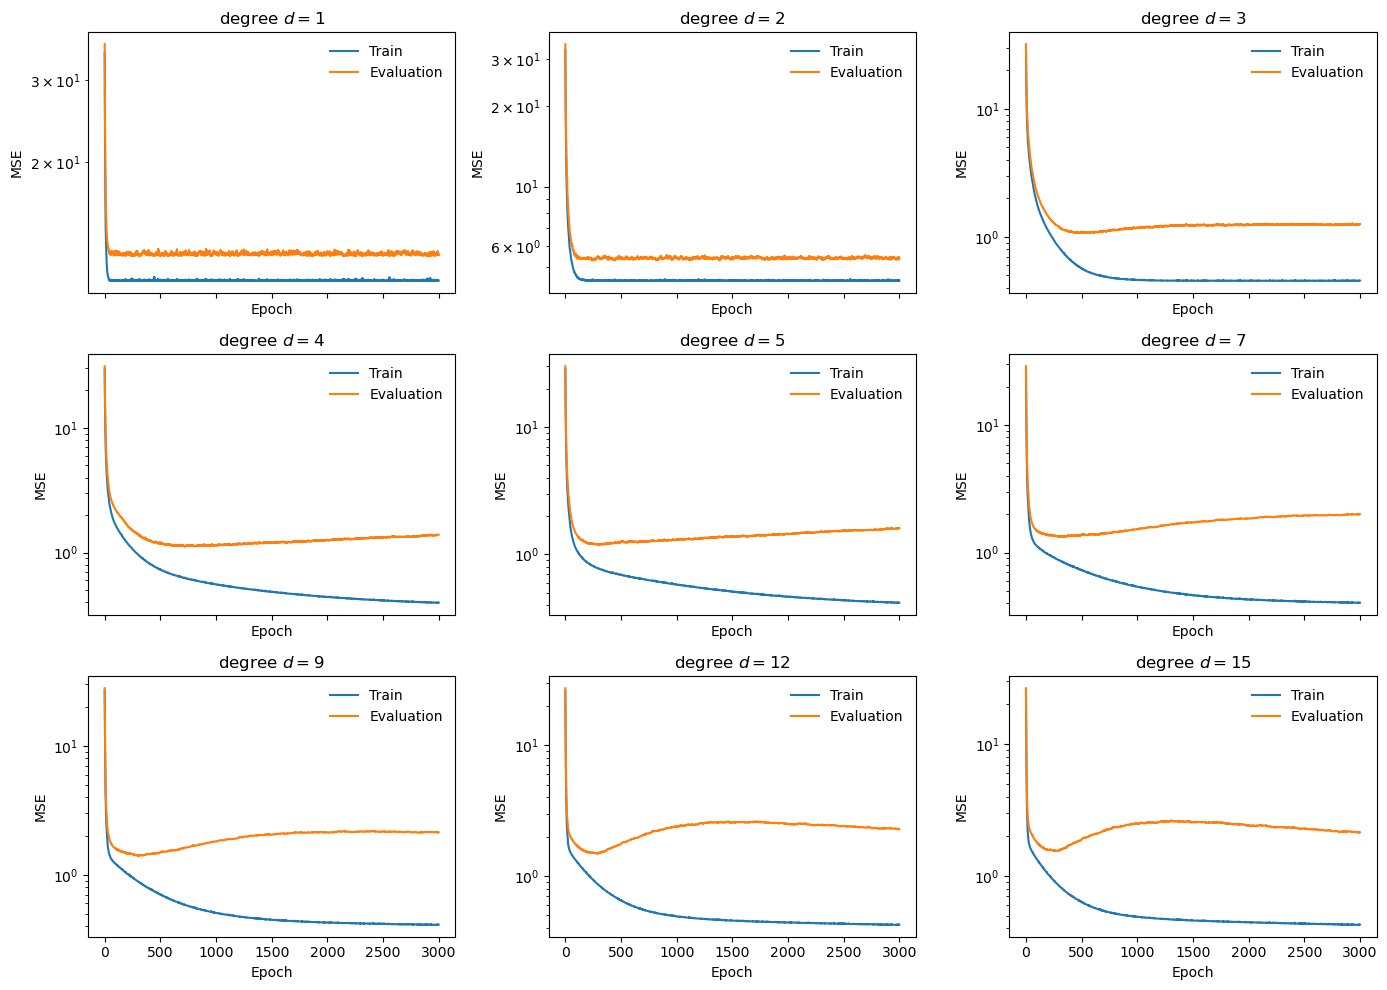

In [233]:
# Plot the learning curves
fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True)
axes = axes.ravel()

for ax, d, train_mse, test_mse in zip(axes, degrees, train_curves, test_curves):
    ax.plot(train_mse, label="Train")
    ax.plot(test_mse, label="Evaluation")
    ax.set_title(f"degree $d={d}$")
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()


Let us now look at the final evaluation error as a function of model complexity.

For this fixed random training set, you should see the characteristic pattern: low-degree models underfit, the degree-3 model is close to the true data-generating function, and sufficiently high-degree models begin to overfit the noise.

The exact curve fluctuates with the sampled training set; the textbook bias--variance curve is most cleanly obtained by averaging over many independently sampled training sets.


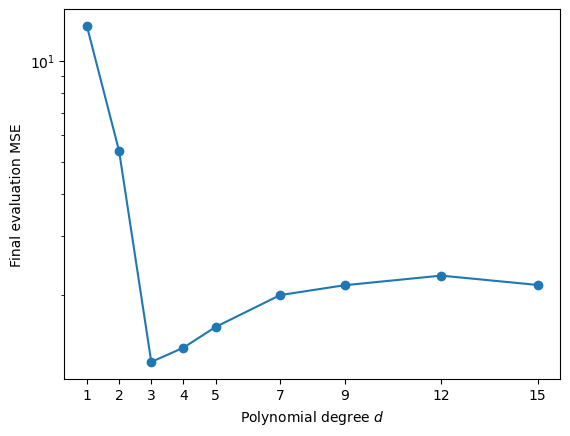

degree  1: evaluation MSE = 12.703
degree  2: evaluation MSE = 5.381
degree  3: evaluation MSE = 1.264
degree  4: evaluation MSE = 1.394
degree  5: evaluation MSE = 1.607
degree  7: evaluation MSE = 2.000
degree  9: evaluation MSE = 2.140
degree 12: evaluation MSE = 2.286
degree 15: evaluation MSE = 2.144


In [234]:
# Plot the final evaluation MSE versus polynomial degree
final_test_mse = test_curves[:, -1]

plt.plot(degrees, final_test_mse, marker="o")
plt.xlabel("Polynomial degree $d$")
plt.ylabel("Final evaluation MSE")
plt.yscale("log")
plt.xticks(degrees)
plt.show()

for d, mse in zip(degrees, final_test_mse):
    print(f"degree {d:2d}: evaluation MSE = {mse:.3f}")


Let us also plot the learned polynomial curves.


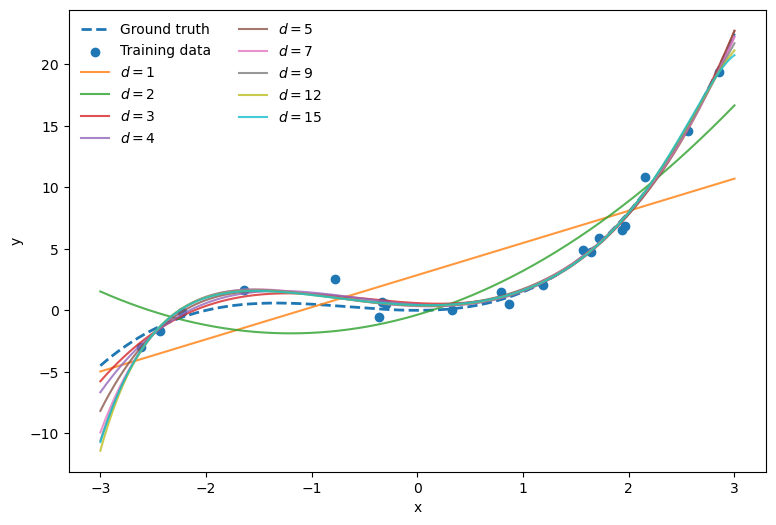

In [235]:
# Plot the learned polynomials
X_plot = np.linspace(-train_bound, train_bound, 400).reshape(-1, 1)
y_true = X_plot[:, 0] ** 2 + 0.5 * X_plot[:, 0] ** 3

plt.figure(figsize=(9, 6))
plt.plot(X_plot[:, 0], y_true, linestyle="--", linewidth=2, label="Ground truth")
plt.scatter(X_train[:, 0], y_train, label="Training data")

for d, c in zip(degrees, coefficients):
    y_pred = predict_label(create_features(X_plot, d, train_bound), c)
    plt.plot(X_plot[:, 0], y_pred, label=f"$d={d}$", alpha=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.legend(frameon=False, ncols=2)
plt.show()


# 2 SGD for Linear Regression on a Health Dataset

In this exercise we load a real-world dataset and implement mini-batch SGD for linear regression.
We then compare our implementation with scikit-learn's `LinearRegression`, which fits the same unregularized least-squares model using a library solver.


In [236]:
# Import the diabetes dataset from scikit-learn
from sklearn.datasets import load_diabetes


In [237]:
# Load the diabetes dataset
diabetes = load_diabetes()

# Inspect the dataset description
print(diabetes.DESCR)


.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [238]:
# Extract the dataset
X = diabetes.data.copy()
y = diabetes.target.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (442, 10)
y shape: (442,)


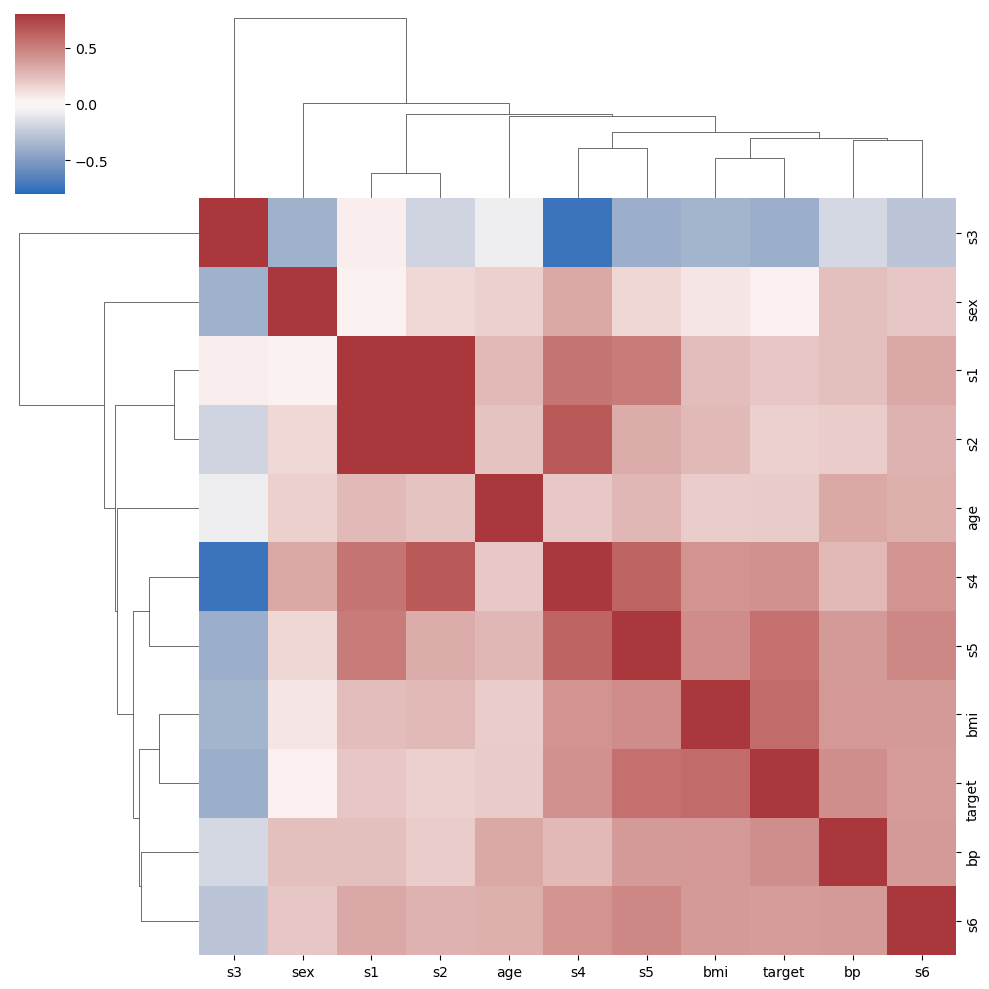

In [239]:
# Visualize correlations between features and the target
import pandas as pd
import seaborn as sns

df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y
corr_mat = df.corr()
sns.clustermap(corr_mat, vmax=0.8, vmin=-0.8, cmap="vlag")
plt.show()


## 2.1 Train/validation/test split and preprocessing

The diabetes input features provided by scikit-learn are already mean-centered and scaled. Nevertheless, we will use a `StandardScaler` here to practice the correct preprocessing workflow.

**Important:** split the dataset first. Fit any preprocessing transformation using **only the training set**, then apply the fitted transformation unchanged to the validation and test sets. This avoids data leakage.

We will use approximately 60% of the examples for training, 20% for validation, and 20% for the final test set. The target is rescaled using a factor computed from the training targets only.


In [240]:
# First create train+validation and test sets, then split train+validation again
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=14
)
X_train, X_validation, y_train, y_validation = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=14
)

print("train / validation / test:", len(X_train), len(X_validation), len(X_test))


train / validation / test: 264 89 89


In [241]:
# Fit preprocessing only on the training data and apply it to all three splits
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_validation = scaler.transform(X_validation)
X_test = scaler.transform(X_test)

y_scale = np.max(np.abs(y_train))
y_train = y_train / y_scale
y_validation = y_validation / y_scale
y_test = y_test / y_scale


## 2.2 Implementing gradients for Linear Regression

We use the linear model

$$
\hat y_i = w^\top x_i + c
$$

and the loss

$$
L(w,c)=\frac{1}{2n}\sum_{i=1}^n (y_i-\hat y_i)^2.
$$

Derive the gradients:

$$
\frac{\partial L}{\partial w}=\; -\frac{1}{n}\sum_{i = 1}^n (y_i-\hat{y_i})x_i,
\qquad
\frac{\partial L}{\partial c}=\; -\frac{1}{n}\sum_{i = 1}^n (y_i-\hat{y_i})
$$

and implement them below.


In [242]:
def grad_w(X, y, w, c):
    # Return partial L / partial w
    y_pred = X @ w + c
    return -(X.T @ (y - y_pred)) / X.shape[0]


In [243]:
def grad_c(X, y, w, c):
    # Return partial L / partial c
    y_pred = X @ w + c
    return -np.mean(y - y_pred)


Implement mini-batch SGD. As in Part 1, each epoch should shuffle the training examples and then use every training example exactly once.

Plot **training and validation MSE** as functions of the epoch. Do not repeatedly use the test set while deciding how long to train or which learning rate to use.


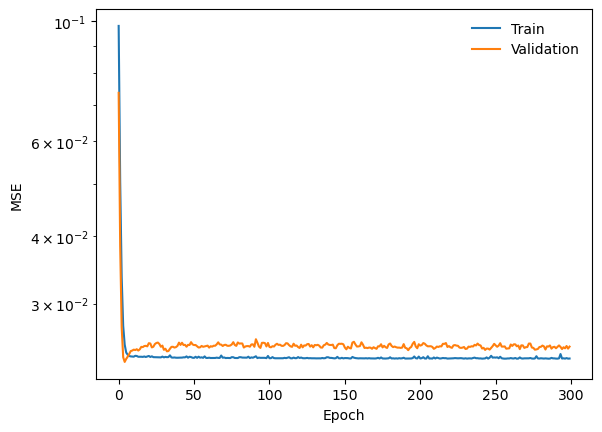

SGD final test MSE = 0.02613


In [244]:
# Set up mini-batch stochastic gradient descent
BATCH_SIZE = 16
EPOCHS = 300
lr = 0.03

w = np.zeros(X_train.shape[1])
c = 0.0
rng = np.random.default_rng(43)

MSE_train = []
MSE_validation = []

for epoch in range(EPOCHS):
    permutation = rng.permutation(X_train.shape[0])

    for start in range(0, len(permutation), BATCH_SIZE):
        idx = permutation[start : start + BATCH_SIZE]
        X_batch = X_train[idx]
        y_batch = y_train[idx]

        # Compute both gradients at the same current parameter values
        dw = grad_w(X_batch, y_batch, w, c)
        dc = grad_c(X_batch, y_batch, w, c)
        w -= lr * dw
        c -= lr * dc

    MSE_train.append(np.mean((y_train - (X_train @ w + c)) ** 2))
    MSE_validation.append(
        np.mean((y_validation - (X_validation @ w + c)) ** 2)
    )

plt.plot(MSE_train, label="Train")
plt.plot(MSE_validation, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.yscale("log")
plt.legend(frameon=False)
plt.show()

MSE_test_sgd = np.mean((y_test - (X_test @ w + c)) ** 2)
print(f"SGD final test MSE = {MSE_test_sgd:.5f}")


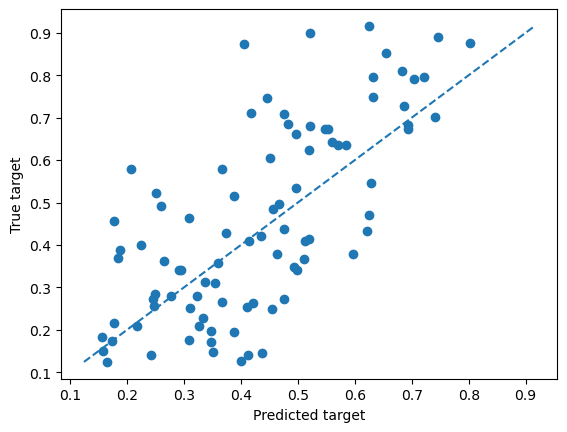

In [ ]:
# Show predictions on the final test set
y_pred_test = X_test @ w + c
plt.scatter(y_pred_test, y_test)
lims = [min(y_pred_test.min(), y_test.min()), max(y_pred_test.max(), y_test.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Predicted target")
plt.ylabel("True target")
plt.show()


1. Explain in your own words what information the training and validation learning curves give you.

**Answer.** The curves show how optimization and generalization evolve during training. A decreasing training loss indicates that SGD is fitting the training data. The validation loss estimates performance on unseen data and can be used to choose hyperparameters or an early-stopping time. If the training loss keeps decreasing while the validation loss starts increasing, this is evidence of overfitting.


## 2.3 Loss Curve Quiz

What is happening in each case? What could be wrong at the level of the GD/SGD algorithm and/or the model used? Which remedies/debugging strategies would you employ?

**L1**  
![L1](https://developers.google.com/static/machine-learning/testing-debugging/images/metric-curve-ex03.svg)

**L2**  
![L2](https://developers.google.com/static/machine-learning/testing-debugging/images/metric-curve-ex02.svg)

**L3**  
![L3](https://developers.google.com/static/machine-learning/testing-debugging/images/metric-curve-ex01.svg)

Source: Google for Developers, *Interpreting loss curves*.


**Solutions**

- **L1:** the training loss oscillates and does not converge smoothly. A learning rate that is too high is a likely cause; problematic examples or batches may also cause instability. Try reducing the learning rate and checking the data.
- **L2:** the loss suddenly explodes. Possible causes include NaNs, extreme outliers, exploding gradients, division by zero, or other anomalous values in the input/engineered data.
- **L3:** training loss continues to decrease while test loss starts increasing. This is overfitting. Possible remedies include reducing model complexity, increasing regularization, or checking that train and test data come from comparable distributions.


## 2.4 Comparison with a Library Solution

We will now compare our SGD implementation of the linear regression model introduced in Section 2.2 with scikit-learn’s `LinearRegression`. Both minimize the same unregularized least-squares objective.

Construct a learning curve as a function of the number of training examples. For a model fitted on the first $i$ training examples, compute its training MSE only on those same $i$ examples, and use the validation set for the out-of-sample curve.


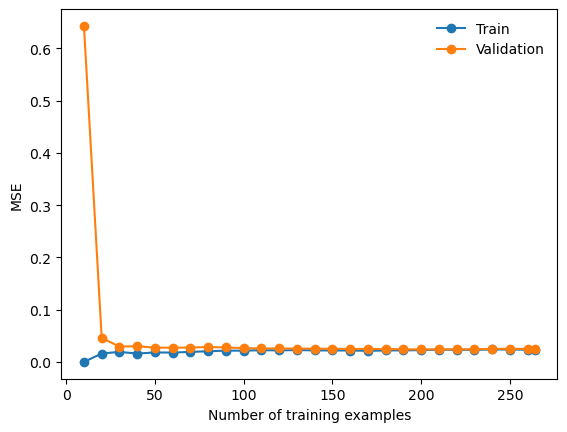

scikit-learn final test MSE = 0.02590
SGD final test MSE          = 0.02613


In [246]:
# Learning curve for scikit-learn LinearRegression
train_sizes = np.arange(10, X_train.shape[0] + 1, 10)
if train_sizes[-1] != X_train.shape[0]:
    train_sizes = np.append(train_sizes, X_train.shape[0])

MSE_train_sklearn = []
MSE_validation_sklearn = []

for i in train_sizes:
    lm = linear_model.LinearRegression(fit_intercept=True).fit(
        X_train[:i], y_train[:i]
    )
    MSE_train_sklearn.append(
        np.mean((y_train[:i] - lm.predict(X_train[:i])) ** 2)
    )
    MSE_validation_sklearn.append(
        np.mean((y_validation - lm.predict(X_validation)) ** 2)
    )

plt.plot(train_sizes, MSE_train_sklearn, marker="o", label="Train")
plt.plot(train_sizes, MSE_validation_sklearn, marker="o", label="Validation")
plt.xlabel("Number of training examples")
plt.ylabel("MSE")
plt.legend(frameon=False)
plt.show()

# Refit on the full training set and evaluate the test set once
lm = linear_model.LinearRegression(fit_intercept=True).fit(X_train, y_train)
MSE_test_sklearn = np.mean((y_test - lm.predict(X_test)) ** 2)
print(f"scikit-learn final test MSE = {MSE_test_sklearn:.5f}")
print(f"SGD final test MSE          = {MSE_test_sgd:.5f}")


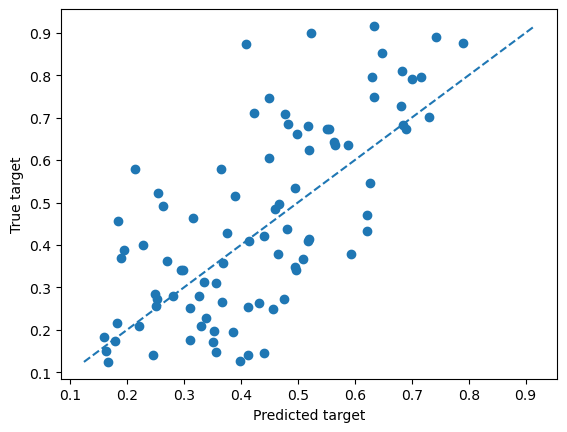

In [247]:
# Show scikit-learn predictions on the test set
y_pred_sklearn = lm.predict(X_test)
plt.scatter(y_pred_sklearn, y_test)
lims = [min(y_pred_sklearn.min(), y_test.min()), max(y_pred_sklearn.max(), y_test.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Predicted target")
plt.ylabel("True target")
plt.show()


1. What is the difference between the two fitting methods if the model and loss are the same?
2. When would you use a library implementation, and when might you write your own optimizer?

**Answer.**

1. Both methods fit the same linear model with the same unregularized squared-error objective. Our implementation uses iterative mini-batch SGD, so its result depends on optimization hyperparameters such as learning rate, batch size, and number of epochs. `LinearRegression` uses a dedicated least-squares solver and does not require these SGD hyperparameters.
2. For standard problems, a mature library implementation is usually preferable because it is tested, efficient, and less error-prone. Writing your own implementation is valuable for learning, for checking derivations, and when you need an optimization procedure or model that the library does not provide.


## 2.5 Validation Data Set

1. Why do we need a validation set?
2. Which hyperparameters does SGD have?
3. How should we estimate the generalization error after hyperparameter tuning?

**Answer.**

1. The validation set is used for model and hyperparameter choices, for example selecting the learning rate, batch size, number of epochs, regularization strength, or an early-stopping time. Repeatedly making such choices from test performance would leak information from the test set into model development.
2. Typical SGD hyperparameters include the learning rate (and possibly a learning-rate schedule), batch size, number of epochs or stopping rule, initialization, and—if present—regularization parameters.
3. After all choices have been frozen using training and validation data, evaluate the chosen model **once** on the untouched test set. The test MSE is then an empirical estimate of the generalization error. With limited data, cross-validation can be used within the training/validation portion, while preserving a final held-out test set for the final report.
